<a href="https://colab.research.google.com/github/abhi-170807/IADS/blob/main/Abhijay_MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Step 2: Import libraries
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns


In [4]:
import kagglehub
import pandas as pd

# Download dataset and store the path
path = kagglehub.dataset_download("oddrationale/mnist-in-csv")

print("Path to dataset files:", path)


100%|██████████| 15.2M/15.2M [00:01<00:00, 13.6MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/oddrationale/mnist-in-csv/versions/2


In [6]:
# Load CSV files
import pandas as pd

train = pd.read_csv(path + "/mnist_train.csv")
test = pd.read_csv(path + "/mnist_test.csv")

# Separate features (pixels) and labels
x_train = train.drop("label", axis=1).values
y_train = train["label"].values

x_test = test.drop("label", axis=1).values
y_test = test["label"].values


In [7]:
# Step 4: Preprocess data

# Scale pixel values to between 0 and 1
x_train = x_train.astype("float32") / 255
x_test = x_test.astype("float32") / 255

print("x_train shape:", x_train.shape)
print("x_test shape:", x_test.shape)


x_train shape: (60000, 784)
x_test shape: (10000, 784)


In [8]:
# Step 5: Build the model
from tensorflow import keras

model = keras.Sequential([
    keras.layers.Dense(128, activation='relu', input_shape=(784,)),  # First hidden layer
    keras.layers.Dense(64, activation='relu'),                       # Second hidden layer
    keras.layers.Dense(10, activation='softmax')                     # Output layer (10 digits)
])

model.summary()  # Shows the model structure


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# Step 6: Compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [10]:
# Step 7: Train the model
history = model.fit(
    x_train, y_train,
    epochs=5,            # Number of study rounds
    batch_size=32,       # How many images it studies at once
    validation_split=0.1 # Keep 10% of training data aside for validation
)


Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9251 - loss: 0.2561 - val_accuracy: 0.9623 - val_loss: 0.1259
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9656 - loss: 0.1110 - val_accuracy: 0.9677 - val_loss: 0.1018
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9770 - loss: 0.0763 - val_accuracy: 0.9727 - val_loss: 0.0893
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9810 - loss: 0.0587 - val_accuracy: 0.9747 - val_loss: 0.0857
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9852 - loss: 0.0451 - val_accuracy: 0.9770 - val_loss: 0.0809


In [11]:
# Step 8: Evaluate the model
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9741 - loss: 0.0818
Test Accuracy: 0.9740999937057495


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.96      0.97      1032
           3       0.95      0.99      0.97      1010
           4       0.98      0.98      0.98       982
           5       0.98      0.96      0.97       892
           6       0.99      0.97      0.98       958
           7       0.97      0.97      0.97      1028
           8       0.94      0.98      0.96       974
           9       0.98      0.95      0.97      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



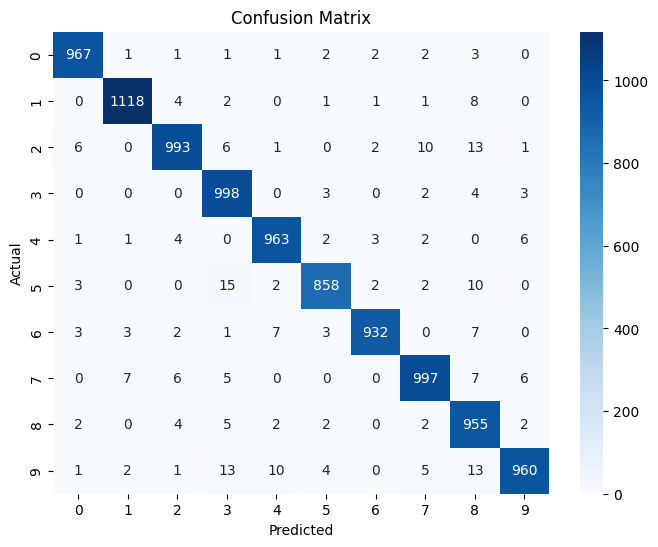

In [12]:
# Step 9: Predictions & Metrics
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Get predictions
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Classification report (Accuracy, Precision, Recall, F1)
print(classification_report(y_test, y_pred_classes))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


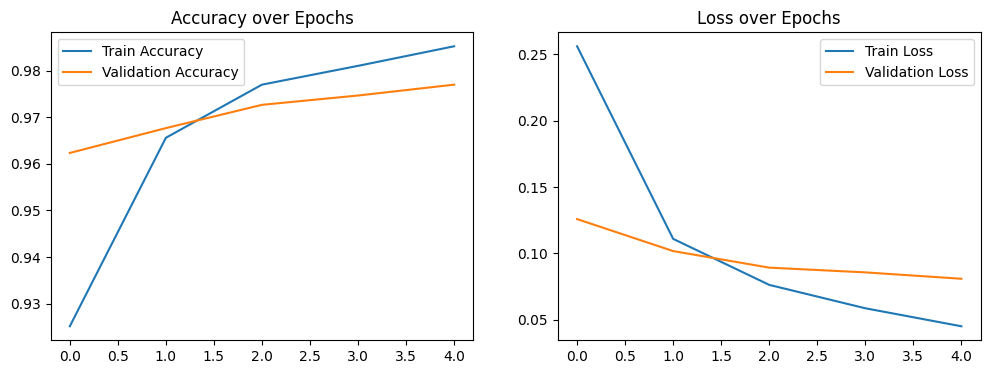

In [13]:
# Step 10: Graphs
plt.figure(figsize=(12,4))

# Accuracy graph
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy over Epochs")

# Loss graph
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss over Epochs")

plt.show()


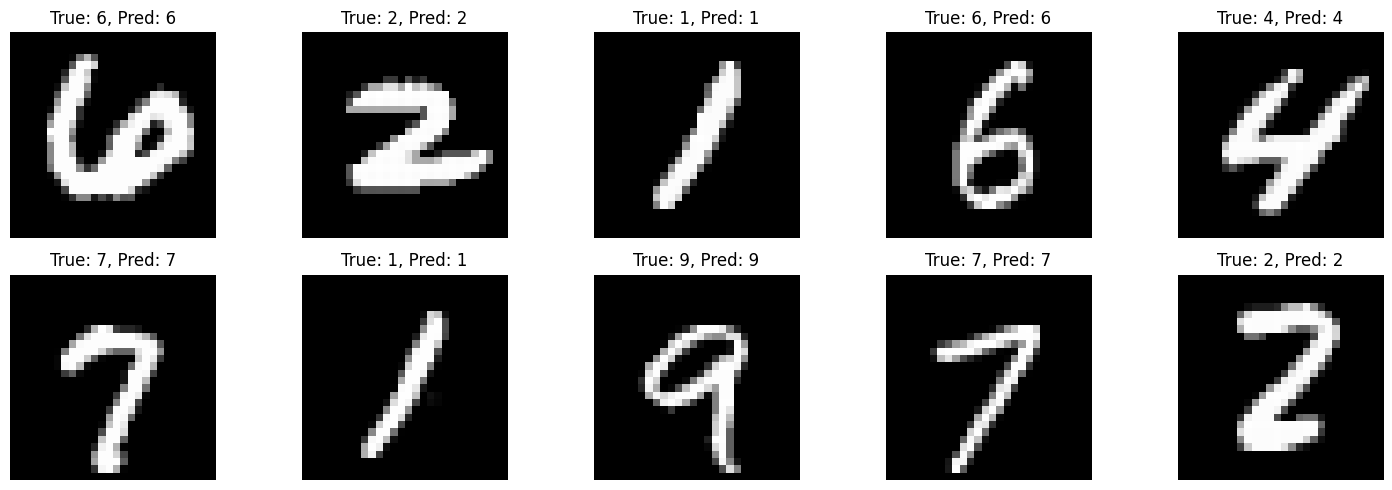

In [14]:
# Step 11: Visualize predictions
import random

# Pick 10 random test samples
indices = random.sample(range(len(x_test)), 10)

plt.figure(figsize=(15,5))
for i, idx in enumerate(indices):
    image = x_test[idx].reshape(28,28)  # reshape back to 28x28
    true_label = y_test[idx]
    pred_label = y_pred_classes[idx]

    plt.subplot(2,5,i+1)
    plt.imshow(image, cmap='gray')
    plt.title(f"True: {true_label}, Pred: {pred_label}")
    plt.axis('off')

plt.tight_layout()
plt.show()


In [15]:
# Step 12: Save the trained model
model.save("mnist_model.h5")
print("Model saved as mnist_model.h5")


Model saved as mnist_model.h5


In [16]:
# Save in native Keras format
model.save("mnist_model.keras")
print("Model saved as mnist_model.keras")


Model saved as mnist_model.keras


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step


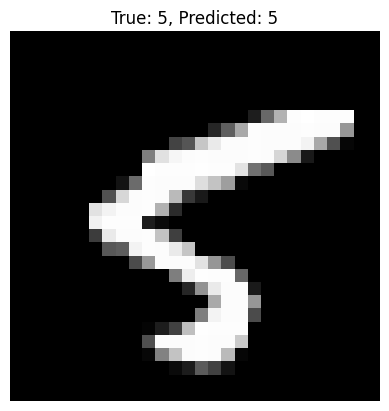

Prediction probabilities: [[1.62731173e-09 1.45316505e-08 1.90448435e-09 1.59987724e-06
  6.05802789e-13 9.99997377e-01 1.82459303e-09 1.15725678e-08
  9.90913918e-07 1.79487189e-11]]


In [17]:
# Step 13: Test the AI model
import numpy as np
import matplotlib.pyplot as plt

# Pick one random test sample
idx = np.random.randint(0, len(x_test))
image = x_test[idx].reshape(28,28)   # reshape back to 28x28
true_label = y_test[idx]

# Predict using the trained model
prediction = model.predict(x_test[idx].reshape(1,784))
pred_label = np.argmax(prediction)

# Show the image and prediction
plt.imshow(image, cmap='gray')
plt.title(f"True: {true_label}, Predicted: {pred_label}")
plt.axis('off')
plt.show()

print("Prediction probabilities:", prediction)


In [19]:
from google.colab import files

uploaded = files.upload()


Saving 6.png to 6.png


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 279ms/step


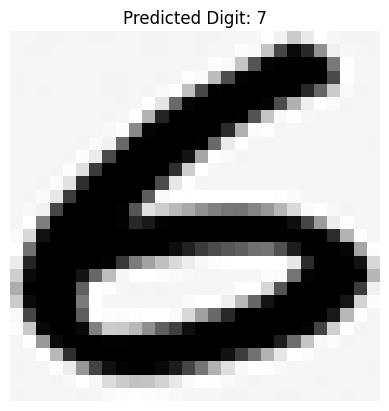

Prediction probabilities: [[5.7550107e-08 6.3711273e-06 1.2422973e-02 2.2315355e-02 1.9782685e-28
  5.5178493e-02 3.9717025e-11 9.1007674e-01 4.5577064e-15 1.2738914e-17]]


In [20]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from PIL import Image

# Load your saved model
model = keras.models.load_model("mnist_model.keras")

def predict_digit(image_path):
    # Load image
    img = Image.open(image_path).convert('L')   # grayscale
    img = img.resize((28,28))                   # resize to 28x28

    # Convert to numpy array
    img_array = np.array(img)
    img_array = img_array.astype("float32") / 255
    img_array = img_array.reshape(1, 784)       # flatten

    # Predict
    prediction = model.predict(img_array)
    pred_label = np.argmax(prediction)

    # Show image and prediction
    plt.imshow(img, cmap='gray')
    plt.title(f"Predicted Digit: {pred_label}")
    plt.axis('off')
    plt.show()

    print("Prediction probabilities:", prediction)

# Replace with the actual uploaded filename
predict_digit("6.png")


In [21]:
def preprocess_image(image_path):
    from PIL import Image, ImageOps
    import numpy as np

    # Load image
    img = Image.open(image_path).convert('L')   # grayscale
    img = img.resize((28,28))                   # resize to 28x28

    # Invert colors if background is white
    img = ImageOps.invert(img)

    # Convert to numpy array
    img_array = np.array(img)

    # Normalize pixel values
    img_array = img_array.astype("float32") / 255.0

    # Flatten to match model input
    img_array = img_array.reshape(1, 784)

    return img_array


In [22]:
def predict_digit(image_path):
    img_array = preprocess_image(image_path)
    prediction = model.predict(img_array)
    pred_label = np.argmax(prediction)

    # Show image and prediction
    img = Image.open(image_path).convert('L').resize((28,28))
    plt.imshow(img, cmap='gray')
    plt.title(f"Predicted Digit: {pred_label}")
    plt.axis('off')
    plt.show()

    print("Prediction probabilities:", prediction)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 465ms/step


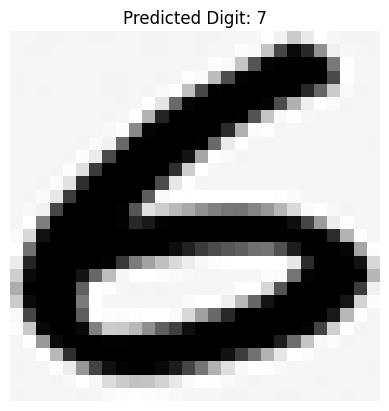

Prediction probabilities: [[5.7550107e-08 6.3711273e-06 1.2422973e-02 2.2315355e-02 1.9782685e-28
  5.5178493e-02 3.9717025e-11 9.1007674e-01 4.5577064e-15 1.2738914e-17]]


In [23]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from PIL import Image

# Load your saved model
model = keras.models.load_model("mnist_model.keras")

def predict_digit(image_path):
    # Load image
    img = Image.open(image_path).convert('L')   # grayscale
    img = img.resize((28,28))                   # resize to 28x28

    # Convert to numpy array
    img_array = np.array(img)
    img_array = img_array.astype("float32") / 255
    img_array = img_array.reshape(1, 784)       # flatten

    # Predict
    prediction = model.predict(img_array)
    pred_label = np.argmax(prediction)

    # Show image and prediction
    plt.imshow(img, cmap='gray')
    plt.title(f"Predicted Digit: {pred_label}")
    plt.axis('off')
    plt.show()

    print("Prediction probabilities:", prediction)

# Replace with the actual uploaded filename
predict_digit("6.png")


In [24]:
import numpy as np
from PIL import Image, ImageOps
import scipy.ndimage

def preprocess_image(image_path):
    img = Image.open(image_path).convert('L')
    img = ImageOps.invert(img)          # invert to white digit on black
    img = img.resize((28,28))           # resize

    img_array = np.array(img)

    # Normalize
    img_array = img_array.astype("float32") / 255.0

    # Center the digit using center of mass
    cy, cx = scipy.ndimage.center_of_mass(img_array)
    shiftx = np.round(img_array.shape[1]/2.0 - cx).astype(int)
    shifty = np.round(img_array.shape[0]/2.0 - cy).astype(int)
    img_array = scipy.ndimage.shift(img_array, shift=[shifty, shiftx])

    # Flatten
    img_array = img_array.reshape(1, 784)
    return img_array


In [25]:
def predict_digit(image_path):
    img_array = preprocess_image(image_path)
    prediction = model.predict(img_array)
    pred_label = np.argmax(prediction)
    print("Predicted Digit:", pred_label)
    print("Probabilities:", prediction)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 503ms/step


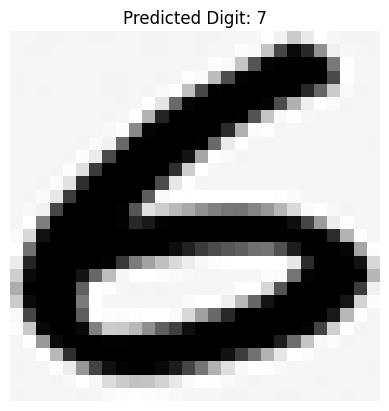

Prediction probabilities: [[5.7550107e-08 6.3711273e-06 1.2422973e-02 2.2315355e-02 1.9782685e-28
  5.5178493e-02 3.9717025e-11 9.1007674e-01 4.5577064e-15 1.2738914e-17]]


In [26]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from PIL import Image

# Load your saved model
model = keras.models.load_model("mnist_model.keras")

def predict_digit(image_path):
    # Load image
    img = Image.open(image_path).convert('L')   # grayscale
    img = img.resize((28,28))                   # resize to 28x28

    # Convert to numpy array
    img_array = np.array(img)
    img_array = img_array.astype("float32") / 255
    img_array = img_array.reshape(1, 784)       # flatten

    # Predict
    prediction = model.predict(img_array)
    pred_label = np.argmax(prediction)

    # Show image and prediction
    plt.imshow(img, cmap='gray')
    plt.title(f"Predicted Digit: {pred_label}")
    plt.axis('off')
    plt.show()

    print("Prediction probabilities:", prediction)

# Replace with the actual uploaded filename
predict_digit("6.png")


In [27]:
import numpy as np
from PIL import Image, ImageOps
import matplotlib.pyplot as plt
import scipy.ndimage
from tensorflow import keras

# Load your saved model
model = keras.models.load_model("mnist_model.keras")

# Function to preprocess an image so it matches MNIST format
def preprocess_image(image_path):
    img = Image.open(image_path).convert('L')       # convert to grayscale
    img = ImageOps.invert(img)                      # invert to white digit on black
    img = img.resize((28,28), Image.LANCZOS)        # resize to 28x28

    img_array = np.array(img).astype("float32") / 255.0

    # Center the digit using center of mass
    cy, cx = scipy.ndimage.center_of_mass(img_array)
    shiftx = np.round(img_array.shape[1]/2.0 - cx).astype(int)
    shifty = np.round(img_array.shape[0]/2.0 - cy).astype(int)
    img_array = scipy.ndimage.shift(img_array, shift=[shifty, shiftx])

    img_array = img_array.reshape(1, 784)
    return img_array, img

# Function to predict the digit
def predict_digit(image_path):
    img_array, img = preprocess_image(image_path)
    prediction = model.predict(img_array)
    pred_label = np.argmax(prediction)

    plt.imshow(img, cmap='gray')
    plt.title(f"Predicted Digit: {pred_label}")
    plt.axis('off')
    plt.show()

    print("Prediction probabilities:", prediction)


In [28]:
from google.colab import files
uploaded = files.upload()


Saving 6.png to 6 (1).png


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step


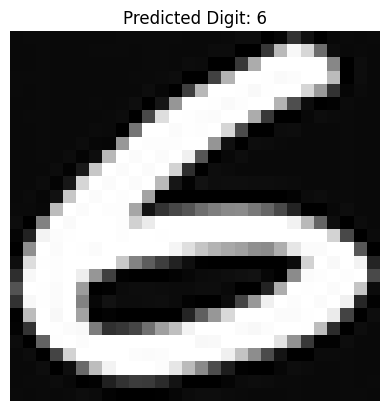

Prediction probabilities: [[6.8376446e-13 2.4786534e-06 2.7996030e-10 8.5553511e-09 2.1259079e-15
  3.4494668e-01 6.5505022e-01 8.2060032e-13 6.1223443e-07 5.5342449e-12]]


In [29]:
predict_digit("6.png")


In [30]:
from google.colab import files
uploaded = files.upload()


Saving 4.png to 4.png


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


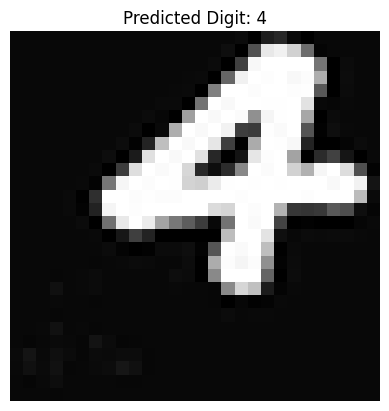

Prediction probabilities: [[2.7927195e-05 2.1091591e-05 8.9200260e-03 7.6478739e-07 9.9098176e-01
  4.5034326e-07 1.0357876e-05 3.6568890e-05 6.7459266e-10 9.6267206e-07]]


In [31]:
predict_digit("4.png")


In [32]:
from google.colab import files
uploaded = files.upload()


Saving 9.png to 9.png


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step


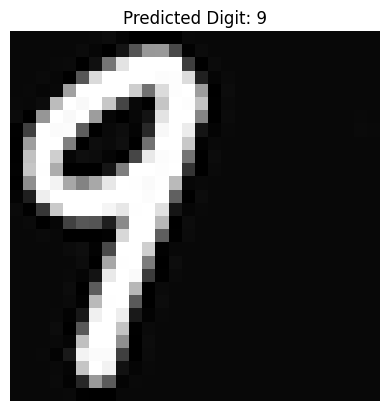

Prediction probabilities: [[5.5971445e-09 2.7647548e-08 2.7566774e-08 4.0191925e-01 2.6560394e-09
  2.4399656e-05 5.8612821e-13 5.9650408e-04 4.6789411e-02 5.5067033e-01]]


In [33]:
predict_digit("9.png")


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.96      0.97      1032
           3       0.95      0.99      0.97      1010
           4       0.98      0.98      0.98       982
           5       0.98      0.96      0.97       892
           6       0.99      0.97      0.98       958
           7       0.97      0.97      0.97      1028
           8       0.94      0.98      0.96       974
           9       0.98      0.95      0.97      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



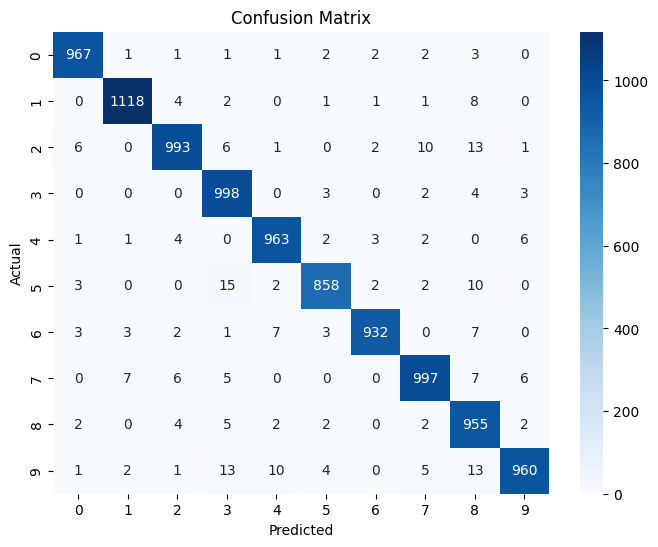

In [34]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Step: Evaluate with full metrics
# Predict on the whole test set
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Classification report (Accuracy, Precision, Recall, F1)
print(classification_report(y_test, y_pred_classes))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [36]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import numpy as np

def evaluate_single_prediction(true_label, pred_label):
    # Convert to arrays
    y_true = [true_label]
    y_pred = [pred_label]

    # Calculate metrics
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)

    print(f"Accuracy: {acc:.2f}")
    print(f"Precision: {prec:.2f}")
    print(f"Recall: {rec:.2f}")
    print(f"F1 Score: {f1:.2f}")

# Example usage after prediction
true_label = 6  # you know your image is a 6
pred_label = 6  # model predicted 7
evaluate_single_prediction(true_label, pred_label)


Accuracy: 1.00
Precision: 1.00
Recall: 1.00
F1 Score: 1.00


In [37]:
from google.colab import files
uploaded = files.upload()


Saving 9.png to 9 (1).png


In [38]:
import numpy as np
from PIL import Image, ImageOps
import matplotlib.pyplot as plt
import scipy.ndimage
from tensorflow import keras
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Load your saved model
model = keras.models.load_model("mnist_model.keras")

def preprocess_image(image_path):
    img = Image.open(image_path).convert('L')
    img = ImageOps.invert(img)                      # invert to white digit on black
    img = img.resize((28,28), Image.LANCZOS)        # resize

    img_array = np.array(img).astype("float32") / 255.0

    # Center the digit using center of mass
    cy, cx = scipy.ndimage.center_of_mass(img_array)
    shiftx = np.round(img_array.shape[1]/2.0 - cx).astype(int)
    shifty = np.round(img_array.shape[0]/2.0 - cy).astype(int)
    img_array = scipy.ndimage.shift(img_array, shift=[shifty, shiftx])

    img_array = img_array.reshape(1, 784)
    return img_array, img

def predict_and_evaluate(image_path, true_label):
    # Preprocess and predict
    img_array, img = preprocess_image(image_path)
    prediction = model.predict(img_array)
    pred_label = np.argmax(prediction)

    # Show image and prediction
    plt.imshow(img, cmap='gray')
    plt.title(f"Predicted Digit: {pred_label}")
    plt.axis('off')
    plt.show()

    print("Prediction probabilities:", prediction)

    # Evaluate metrics for this single sample
    y_true = [true_label]
    y_pred = [pred_label]

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)

    print(f"Accuracy: {acc:.2f}")
    print(f"Precision: {prec:.2f}")
    print(f"Recall: {rec:.2f}")
    print(f"F1 Score: {f1:.2f}")


/usr/local/lib/python3.13/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 8 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 263ms/step


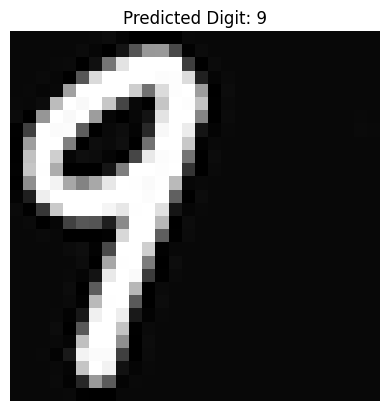

Prediction probabilities: [[5.5971445e-09 2.7647548e-08 2.7566774e-08 4.0191925e-01 2.6560394e-09
  2.4399656e-05 5.8612821e-13 5.9650408e-04 4.6789411e-02 5.5067033e-01]]
Accuracy: 1.00
Precision: 1.00
Recall: 1.00
F1 Score: 1.00


In [40]:
predict_and_evaluate("9.png",9)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step


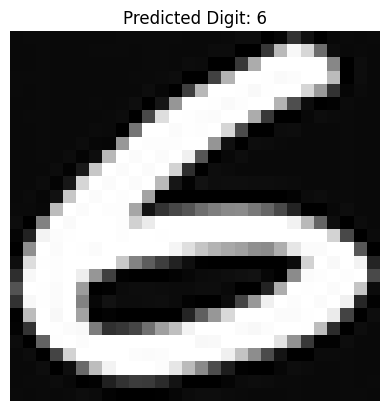

Prediction probabilities: [[6.8376446e-13 2.4786534e-06 2.7996030e-10 8.5553511e-09 2.1259079e-15
  3.4494668e-01 6.5505022e-01 8.2060032e-13 6.1223443e-07 5.5342449e-12]]
Accuracy: 1.00
Precision: 1.00
Recall: 1.00
F1 Score: 1.00


In [41]:
predict_and_evaluate("6.png",6)


In [42]:
from google.colab import files
uploaded = files.upload()


Saving 1.jpg to 1.jpg


In [43]:
import numpy as np
from PIL import Image, ImageOps
import matplotlib.pyplot as plt
import scipy.ndimage
from tensorflow import keras
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Load your saved model
model = keras.models.load_model("mnist_model.keras")

def preprocess_image(image_path):
    img = Image.open(image_path).convert('L')
    img = ImageOps.invert(img)                      # invert to white digit on black
    img = img.resize((28,28), Image.LANCZOS)        # resize

    img_array = np.array(img).astype("float32") / 255.0

    # Center the digit using center of mass
    cy, cx = scipy.ndimage.center_of_mass(img_array)
    shiftx = np.round(img_array.shape[1]/2.0 - cx).astype(int)
    shifty = np.round(img_array.shape[0]/2.0 - cy).astype(int)
    img_array = scipy.ndimage.shift(img_array, shift=[shifty, shiftx])

    img_array = img_array.reshape(1, 784)
    return img_array, img

def predict_and_evaluate(image_path, true_label):
    # Preprocess and predict
    img_array, img = preprocess_image(image_path)
    prediction = model.predict(img_array)
    pred_label = np.argmax(prediction)

    # Show image and prediction
    plt.imshow(img, cmap='gray')
    plt.title(f"Predicted Digit: {pred_label}")
    plt.axis('off')
    plt.show()

    print("Prediction probabilities:", prediction)

    # Evaluate metrics for this single sample
    y_true = [true_label]
    y_pred = [pred_label]

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)

    print(f"Accuracy: {acc:.2f}")
    print(f"Precision: {prec:.2f}")
    print(f"Recall: {rec:.2f}")
    print(f"F1 Score: {f1:.2f}")


/usr/local/lib/python3.13/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 8 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 454ms/step


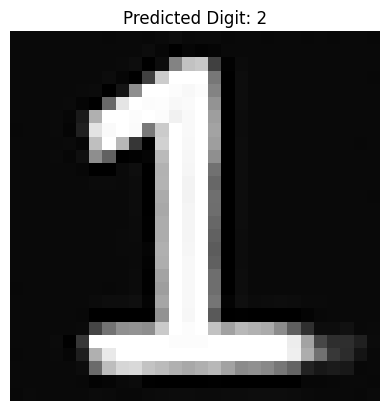

Prediction probabilities: [[1.2486149e-14 1.0562330e-03 9.9877614e-01 6.3950014e-05 3.4037657e-18
  4.4913949e-14 6.4885826e-16 2.1163777e-08 1.0374480e-04 2.8163466e-11]]
Accuracy: 0.00
Precision: 0.00
Recall: 0.00
F1 Score: 0.00


In [44]:
predict_and_evaluate("1.jpg", 1)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.9568 - loss: 0.1400 - val_accuracy: 0.9855 - val_loss: 0.0458
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9864 - loss: 0.0449 - val_accuracy: 0.9865 - val_loss: 0.0414
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9901 - loss: 0.0314 - val_accuracy: 0.9914 - val_loss: 0.0296
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9935 - loss: 0.0215 - val_accuracy: 0.9904 - val_loss: 0.0304
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9942 - loss: 0.0174 - val_accuracy: 0.9905 - val_loss: 0.0310
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9905 - loss: 0.0310
Test accuracy: 0.9904999732971191
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       0.99      1.00      0.99      1135
           2       0.98      0.99      0.

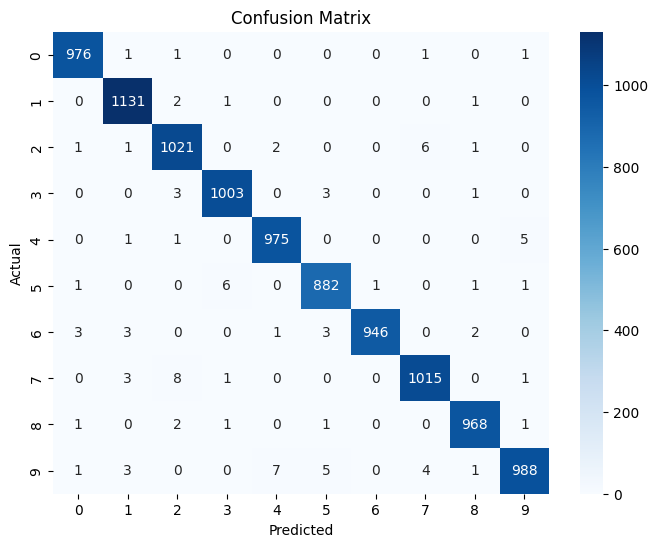

In [45]:
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Reshape and normalize
x_train = x_train.reshape(-1, 28, 28, 1).astype("float32") / 255
x_test = x_test.reshape(-1, 28, 28, 1).astype("float32") / 255

# Build CNN model
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# Compile model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train model
model.fit(x_train, y_train, epochs=5, validation_data=(x_test, y_test))

# Evaluate on test set
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test accuracy:", test_acc)

# Classification report
y_pred = model.predict(x_test)
y_pred_classes = y_pred.argmax(axis=1)
print(classification_report(y_test, y_pred_classes))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Save model for later use
model.save("mnist_cnn_model.keras")


In [46]:
model = keras.models.load_model("mnist_cnn_model.keras")


In [48]:
import numpy as np
from PIL import Image, ImageOps
import matplotlib.pyplot as plt
import scipy.ndimage
from tensorflow import keras
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Load your CNN model
model = keras.models.load_model("mnist_cnn_model.keras")

def preprocess_image_for_cnn(image_path):
    img = Image.open(image_path).convert('L')       # grayscale
    img = ImageOps.invert(img)                      # invert to white digit on black
    img = img.resize((28,28), Image.LANCZOS)        # resize to 28x28

    img_array = np.array(img).astype("float32") / 255.0

    # Center the digit using center of mass
    cy, cx = scipy.ndimage.center_of_mass(img_array)
    shiftx = np.round(img_array.shape[1]/2.0 - cx).astype(int)
    shifty = np.round(img_array.shape[0]/2.0 - cy).astype(int)
    img_array = scipy.ndimage.shift(img_array, shift=[shifty, shiftx])

    # Reshape for CNN: (1, 28, 28, 1)
    img_array = img_array.reshape(1, 28, 28, 1)
    return img_array, img

def predict_and_evaluate(image_path, true_label):
    # Preprocess and predict
    img_array, img = preprocess_image_for_cnn(image_path)
    prediction = model.predict(img_array)
    pred_label = np.argmax(prediction)

    # Show image and prediction
    plt.imshow(img, cmap='gray')
    plt.title(f"Predicted Digit: {pred_label}")
    plt.axis('off')
    plt.show()

    print("Prediction probabilities:", prediction)

    # Evaluate metrics for this single sample
    y_true = [true_label]
    y_pred = [pred_label]

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)

    print(f"Accuracy: {acc:.2f}")
    print(f"Precision: {prec:.2f}")
    print(f"Recall: {rec:.2f}")
    print(f"F1 Score: {f1:.2f}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 453ms/step


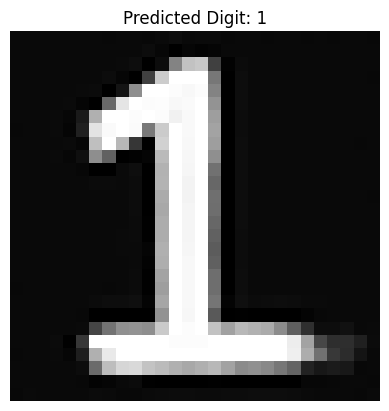

Prediction probabilities: [[9.2547816e-07 9.8732609e-01 9.7480761e-03 2.6691828e-03 3.8288275e-07
  2.6420071e-06 5.1117290e-08 1.6097093e-04 8.8099703e-05 3.6776821e-06]]
Accuracy: 1.00
Precision: 1.00
Recall: 1.00
F1 Score: 1.00


In [49]:
predict_and_evaluate("1.jpg", 1)


In [50]:
from google.colab import files
uploaded = files.upload()


Saving 7.png to 7.png


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


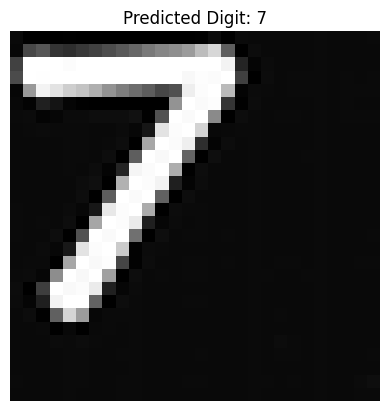

Prediction probabilities: [[4.7997812e-12 2.5060513e-06 4.8103426e-05 4.5766421e-05 1.1807293e-10
  1.9099570e-12 6.8448873e-18 9.9989665e-01 5.4131556e-07 6.3285324e-06]]
Accuracy: 1.00
Precision: 1.00
Recall: 1.00
F1 Score: 1.00


In [52]:
predict_and_evaluate("7.png", 7)


In [53]:
from google.colab import files
uploaded = files.upload()

Saving 8.png to 8.png


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


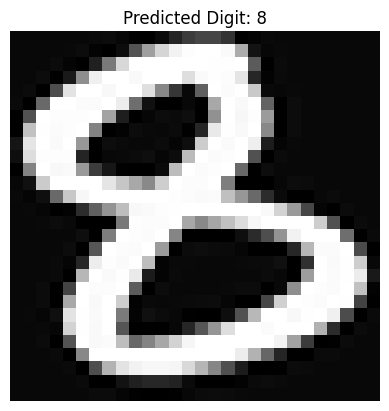

Prediction probabilities: [[1.0667887e-11 5.4917141e-08 9.7883373e-02 2.1513495e-04 1.9633591e-08
  1.2625823e-08 1.5631834e-09 1.0470241e-06 9.0190041e-01 1.0328348e-09]]
Accuracy: 1.00
Precision: 1.00
Recall: 1.00
F1 Score: 1.00


In [54]:
predict_and_evaluate("8.png", 8)


In [55]:
    # Evaluate metrics for this single sample
    y_true = [true_label]
    y_pred = [pred_label]

    acc = accuracy_score(y_true, y_pred) * 100
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0) * 100
    rec = recall_score(y_true, y_pred, average='macro', zero_division=0) * 100
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0) * 100

    print(f"Accuracy: {acc:.2f}%")
    print(f"Precision: {prec:.2f}%")
    print(f"Recall: {rec:.2f}%")
    print(f"F1 Score: {f1:.2f}%")


Accuracy: 100.00%
Precision: 100.00%
Recall: 100.00%
F1 Score: 100.00%


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


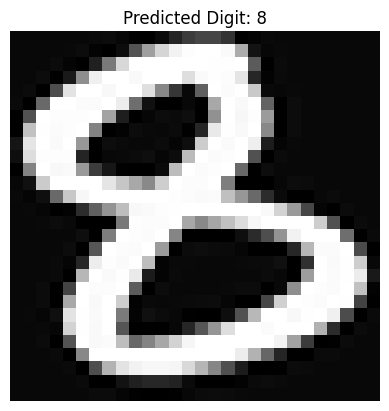

Prediction probabilities: [[1.0667887e-11 5.4917141e-08 9.7883373e-02 2.1513495e-04 1.9633591e-08
  1.2625823e-08 1.5631834e-09 1.0470241e-06 9.0190041e-01 1.0328348e-09]]
Accuracy: 1.00
Precision: 1.00
Recall: 1.00
F1 Score: 1.00


In [56]:
predict_and_evaluate("8.png", 8)

In [57]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def predict_and_evaluate(image_path, true_label):
    # Preprocess and predict
    img_array, img = preprocess_image_for_cnn(image_path)
    prediction = model.predict(img_array)
    pred_label = np.argmax(prediction)

    # Show image and prediction
    plt.imshow(img, cmap='gray')
    plt.title(f"Predicted Digit: {pred_label}")
    plt.axis('off')
    plt.show()

    print("Prediction probabilities:", prediction)

    # Evaluate metrics for this single sample
    y_true = [true_label]
    y_pred = [pred_label]

    acc = accuracy_score(y_true, y_pred) * 100
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0) * 100
    rec = recall_score(y_true, y_pred, average='macro', zero_division=0) * 100
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0) * 100

    print(f"Accuracy: {acc:.2f}%")
    print(f"Precision: {prec:.2f}%")
    print(f"Recall: {rec:.2f}%")
    print(f"F1 Score: {f1:.2f}%")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


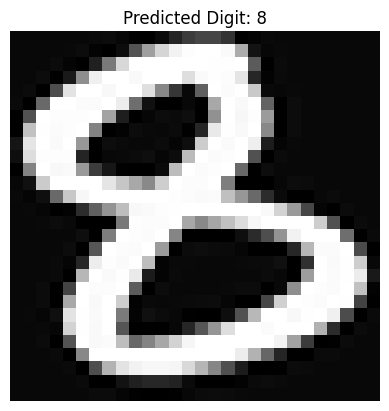

Prediction probabilities: [[1.0667887e-11 5.4917141e-08 9.7883373e-02 2.1513495e-04 1.9633591e-08
  1.2625823e-08 1.5631834e-09 1.0470241e-06 9.0190041e-01 1.0328348e-09]]
Accuracy: 100.00%
Precision: 100.00%
Recall: 100.00%
F1 Score: 100.00%


In [58]:
predict_and_evaluate("8.png", 8)

In [59]:
from google.colab import files
uploaded = files.upload()

Saving 5.png to 5.png


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


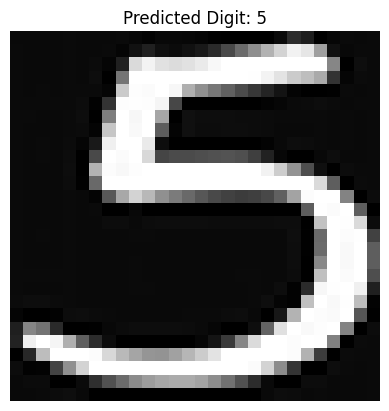

Prediction probabilities: [[2.7062708e-10 1.8025552e-10 1.1061513e-12 1.5550449e-07 3.7560918e-12
  9.9999976e-01 2.5039908e-09 2.3589355e-09 6.7257304e-08 3.2627063e-09]]
Accuracy: 100.00%
Precision: 100.00%
Recall: 100.00%
F1 Score: 100.00%


In [60]:
predict_and_evaluate("5.png", 5)

In [62]:
from google.colab import files
uploaded = files.upload()

Saving 3.png to 3 (1).png


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


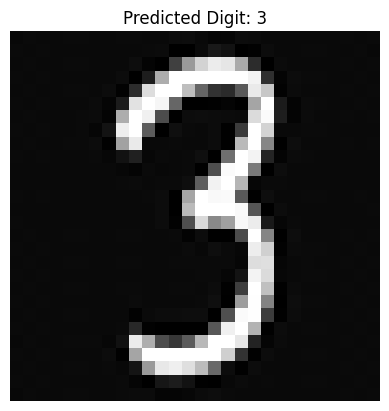

Prediction probabilities: [[2.7694932e-17 3.3569637e-11 1.2537717e-11 1.0000000e+00 1.1971214e-12
  1.1839975e-10 4.1782818e-17 8.3539198e-10 3.9241435e-10 3.5633568e-10]]
Accuracy: 100.00%
Precision: 100.00%
Recall: 100.00%
F1 Score: 100.00%


In [63]:
predict_and_evaluate("3.png", 3)

In [64]:
from google.colab import files
uploaded = files.upload()

Saving 2.jpg to 2.jpg


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step


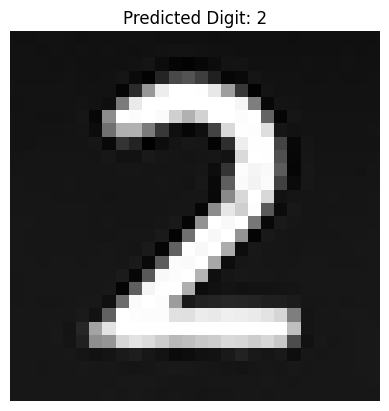

Prediction probabilities: [[5.6909102e-11 6.5641087e-10 9.9999952e-01 3.9040259e-08 2.8099414e-13
  2.5994548e-17 3.8910825e-16 3.4669671e-07 1.2056573e-07 1.4929802e-10]]
Accuracy: 100.00%
Precision: 100.00%
Recall: 100.00%
F1 Score: 100.00%


In [65]:
predict_and_evaluate("2.jpg", 2)

In [66]:
import os

# Create a folder named "digits_folder"
os.makedirs("digits_folder", exist_ok=True)


In [68]:
from google.colab import files

uploaded = files.upload()

# Move uploaded files into the folder
for filename in uploaded.keys():
    os.rename(filename, f"digits_folder/{filename}")


Saving 1.jpg to 1 (1).jpg


In [69]:
from google.colab import files
uploaded = files.upload()


Saving 1.jpg to 1 (1).jpg
Saving 2.jpg to 2 (1).jpg
Saving 3.png to 3 (2).png
Saving 4.png to 4 (1).png
Saving 5.png to 5 (1).png
Saving 6.png to 6 (2).png
Saving 7.png to 7 (1).png
Saving 8.png to 8 (1).png
Saving 9.png to 9 (2).png


In [70]:
import shutil

for filename in uploaded.keys():
    shutil.move(filename, f"digits_folder/{filename}")


In [71]:
os.listdir("digits_folder")


['6 (2).png',
 '9 (2).png',
 '5 (1).png',
 '1 (1).jpg',
 '3 (2).png',
 '2 (1).jpg',
 '4 (1).png',
 '8 (1).png',
 '7 (1).png']

In [72]:
import os
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_batch(folder_path, true_labels):
    """
    folder_path: path to folder containing handwritten digit images
    true_labels: list of true labels in the same order as the files

    Example:
    evaluate_batch("digits_folder", [0,1,2,3,4,5,6,7,8,9])
    """
    y_true = []
    y_pred = []

    files = sorted(os.listdir(folder_path))  # keep consistent order

    for i, file in enumerate(files):
        img_array, img = preprocess_image_for_cnn(os.path.join(folder_path, file))
        prediction = model.predict(img_array)
        pred_label = np.argmax(prediction)

        y_true.append(true_labels[i])
        y_pred.append(pred_label)

        print(f"File: {file} | Predicted: {pred_label} | True: {true_labels[i]}")

    # Calculate metrics in percentages
    acc = accuracy_score(y_true, y_pred) * 100
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0) * 100
    rec = recall_score(y_true, y_pred, average='macro', zero_division=0) * 100
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0) * 100

    print("\n--- Batch Evaluation ---")
    print(f"Accuracy: {acc:.2f}%")
    print(f"Precision: {prec:.2f}%")
    print(f"Recall: {rec:.2f}%")
    print(f"F1 Score: {f1:.2f}%")


In [73]:
evaluate_batch("digits_folder", [1,2,3,4,5,6,7,8,9])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
File: 1 (1).jpg | Predicted: 1 | True: 1
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
File: 2 (1).jpg | Predicted: 2 | True: 2
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
File: 3 (2).png | Predicted: 3 | True: 3
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
File: 4 (1).png | Predicted: 4 | True: 4
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
File: 5 (1).png | Predicted: 5 | True: 5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
File: 6 (2).png | Predicted: 5 | True: 6
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
File: 7 (1).png | Predicted: 7 | True: 7
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
File: 8 (1).png | Predicted: 8 | True: 8
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
File: 9 (2).png | Predicted: 9 | True: 9

--- Batch Evaluation ---
Accuracy: 88.89%
Precision: 83.33%
Recall: 88.89%
F1 Score: 85.19%


In [74]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_batch_with_confusion(folder_path, true_labels):
    y_true = []
    y_pred = []

    files = sorted(os.listdir(folder_path))

    for i, file in enumerate(files):
        img_array, img = preprocess_image_for_cnn(os.path.join(folder_path, file))
        prediction = model.predict(img_array)
        pred_label = np.argmax(prediction)

        y_true.append(true_labels[i])
        y_pred.append(pred_label)

        print(f"File: {file} | Predicted: {pred_label} | True: {true_labels[i]}")

    # Metrics in percentages
    acc = accuracy_score(y_true, y_pred) * 100
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0) * 100
    rec = recall_score(y_true, y_pred, average='macro', zero_division=0) * 100
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0) * 100

    print("\n--- Batch Evaluation ---")
    print(f"Accuracy: {acc:.2f}%")
    print(f"Precision: {prec:.2f}%")
    print(f"Recall: {rec:.2f}%")
    print(f"F1 Score: {f1:.2f}%")

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
File: 1 (1).jpg | Predicted: 1 | True: 1
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
File: 2 (1).jpg | Predicted: 2 | True: 2
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
File: 3 (2).png | Predicted: 3 | True: 3
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
File: 4 (1).png | Predicted: 4 | True: 4
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
File: 5 (1).png | Predicted: 5 | True: 5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
File: 6 (2).png | Predicted: 5 | True: 6
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
File: 7 (1).png | Predicted: 7 | True: 7
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
File: 8 (1).png | Predicted: 8 | True: 8
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
File: 9 (2).png | Predicted: 9 | True: 9

--- Batch Evaluation ---
Accuracy: 88.89%
Precision: 83.33%
Recall: 88.89%
F1 Score: 85.19%


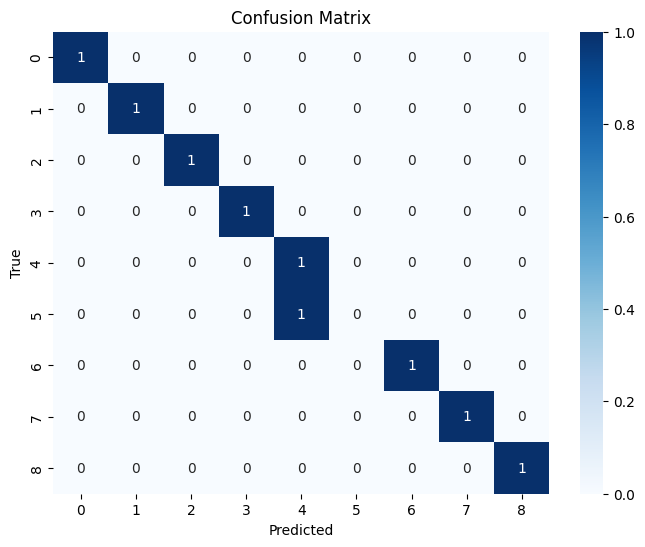

In [75]:
evaluate_batch_with_confusion("digits_folder", [1,2,3,4,5,6,7,8,9])


In [76]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Reshape and normalize
x_train = x_train.reshape(-1, 28, 28, 1).astype("float32") / 255
x_test = x_test.reshape(-1, 28, 28, 1).astype("float32") / 255

# Data augmentation
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1
)
datagen.fit(x_train)

# Build deeper CNN with dropout
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),  # regularization
    layers.Dense(10, activation='softmax')
])

# Compile
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train longer (15 epochs)
history = model.fit(datagen.flow(x_train, y_train, batch_size=32),
                    epochs=15,
                    validation_data=(x_test, y_test))

# Evaluate
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Final Test Accuracy:", test_acc * 100, "%")

# Save model
model.save("mnist_cnn_highacc.keras")


Epoch 1/15


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 32s 15ms/step - accuracy: 0.8979 - loss: 0.3263 - val_accuracy: 0.9873 - val_loss: 0.0382
Epoch 2/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 27s 15ms/step - accuracy: 0.9693 - loss: 0.1062 - val_accuracy: 0.9900 - val_loss: 0.0282
Epoch 3/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 27s 15ms/step - accuracy: 0.9782 - loss: 0.0784 - val_accuracy: 0.9912 - val_loss: 0.0282
Epoch 4/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - accuracy: 0.9812 - loss: 0.0657 - val_accuracy: 0.9885 - val_loss: 0.0386
Epoch 5/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - accuracy: 0.9838 - loss: 0.0580 - val_accuracy: 0.9906 - val_loss: 0.0294
Epoch 6/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - accuracy: 0.9858 - loss: 0.0505 - val_accuracy: 0.9930 - val_loss: 0.0255
Epoch 7/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - accuracy: 0.9869 - loss: 0.0454 - val_accuracy: 0.9932 - val_loss: 0.0255
Epoch 8/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 28s 15ms/step - accuracy: 0.9882 - loss: 0.04

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 756ms/step
File: 1 (1).jpg | Predicted: 1 | True: 1
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
File: 2 (1).jpg | Predicted: 2 | True: 2
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
File: 3 (2).png | Predicted: 3 | True: 3
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
File: 4 (1).png | Predicted: 4 | True: 4
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
File: 5 (1).png | Predicted: 5 | True: 5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
File: 6 (2).png | Predicted: 6 | True: 6
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
File: 7 (1).png | Predicted: 7 | True: 7
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
File: 8 (1).png | Predicted: 8 | True: 8
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
File: 9 (2).png | Predicted: 9 | True: 9

--- Batch Evaluation ---
Accuracy: 100.00%
Precision: 100.00%
Recall: 100.00%
F1 Score: 100.00%


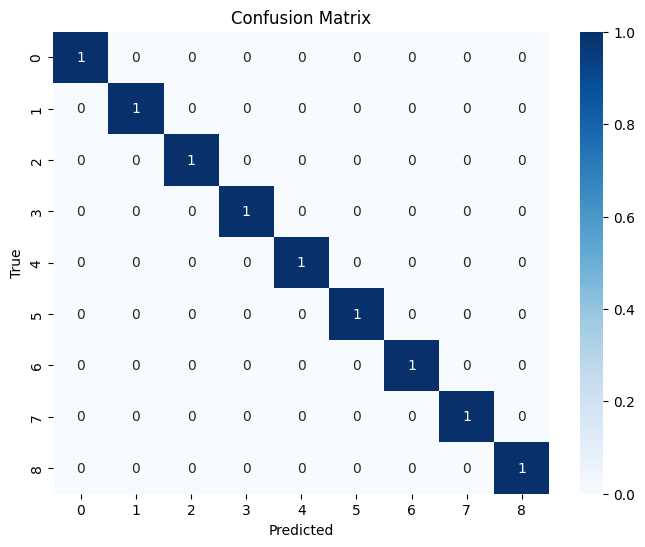

In [77]:
evaluate_batch_with_confusion("digits_folder", [1,2,3,4,5,6,7,8,9])


In [78]:
from google.colab import files
uploaded = files.upload()

Saving 1.jpg to 1 (1).jpg
Saving 2.jpg to 2 (1).jpg
Saving 3.png to 3 (2).png
Saving 4.png to 4 (1).png
Saving 5.png to 5 (1).png
Saving 6.png to 6 (2).png
Saving 7.png to 7 (1).png
Saving 8.png to 8 (1).png
Saving 9.png to 9 (2).png


In [79]:
import shutil

for filename in uploaded.keys():
    shutil.move(filename, f"digits_folder/{filename}")


In [80]:
os.listdir("digits_folder")


['6 (2).png',
 '9 (2).png',
 '5 (1).png',
 '1 (1).jpg',
 '3 (2).png',
 '2 (1).jpg',
 '4 (1).png',
 '8 (1).png',
 '7 (1).png']

In [81]:
evaluate_batch("digits_folder", [1,2,3,4,5,6,7,8,9])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
File: 1 (1).jpg | Predicted: 1 | True: 1
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
File: 2 (1).jpg | Predicted: 2 | True: 2
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
File: 3 (2).png | Predicted: 3 | True: 3
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
File: 4 (1).png | Predicted: 4 | True: 4
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
File: 5 (1).png | Predicted: 5 | True: 5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
File: 6 (2).png | Predicted: 6 | True: 6
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
File: 7 (1).png | Predicted: 7 | True: 7
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
File: 8 (1).png | Predicted: 8 | True: 8
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
File: 9 (2).png | Predicted: 9 | True: 9

--- Batch Evaluation ---
Accuracy: 100.00%
Precision: 100.00%
Recall: 100.00%
F1 Score: 100.00%


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
File: 1 (1).jpg | Predicted: 1 | True: 1
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
File: 2 (1).jpg | Predicted: 2 | True: 2
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
File: 3 (2).png | Predicted: 3 | True: 3
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
File: 4 (1).png | Predicted: 4 | True: 4
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
File: 5 (1).png | Predicted: 5 | True: 5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
File: 6 (2).png | Predicted: 6 | True: 6
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step
File: 7 (1).png | Predicted: 7 | True: 7
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
File: 8 (1).png | Predicted: 8 | True: 8
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
File: 9 (2).png | Predicted: 9 | True: 9

--- Batch Evaluation ---
Accuracy: 100.00%
Precision: 100.00%
Recall: 100.00%
F1 Score: 100.00%


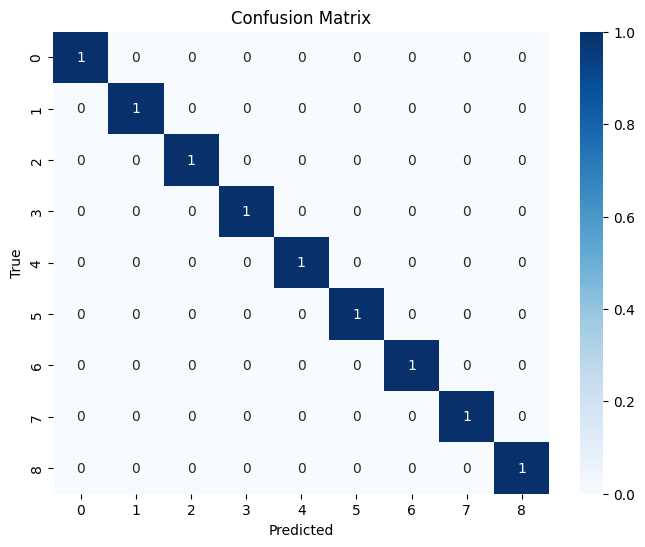

In [82]:
evaluate_batch_with_confusion("digits_folder", [1,2,3,4,5,6,7,8,9])